# Survival models

In [1]:
import sys
sys.path.insert(0, '../')
import polars as pl
from src.LifeTable import LifeTable
from src.SurvivalModelParametric import SurvivalModelParametric
from src.Utils import plot_mortality_rate

## 1. Life Tables

### Small introduction

In [2]:
# Load StatBel data
df_BE_mortality = pl.read_csv("../data/BE_mortality.csv")
df_BE_M_2024 = df_BE_mortality['BE_M_2024']
df_BE_F_2024 = df_BE_mortality['BE_F_2024']
df_BE_M_2020 = df_BE_mortality['BE_M_2020']
df_BE_F_2020 = df_BE_mortality['BE_F_2020']

In [3]:
# Create LifeTable instances
lt_BE_M_2024 = LifeTable(df_BE_M_2024, description = "Belgian Male 2024")
lt_BE_F_2024 = LifeTable(df_BE_F_2024, description = "Belgian Female 2024")
lt_BE_M_2020 = LifeTable(df_BE_M_2020, description = "Belgian Male 2020")
lt_BE_F_2020 = LifeTable(df_BE_F_2020, description = "Belgian Female 2020")

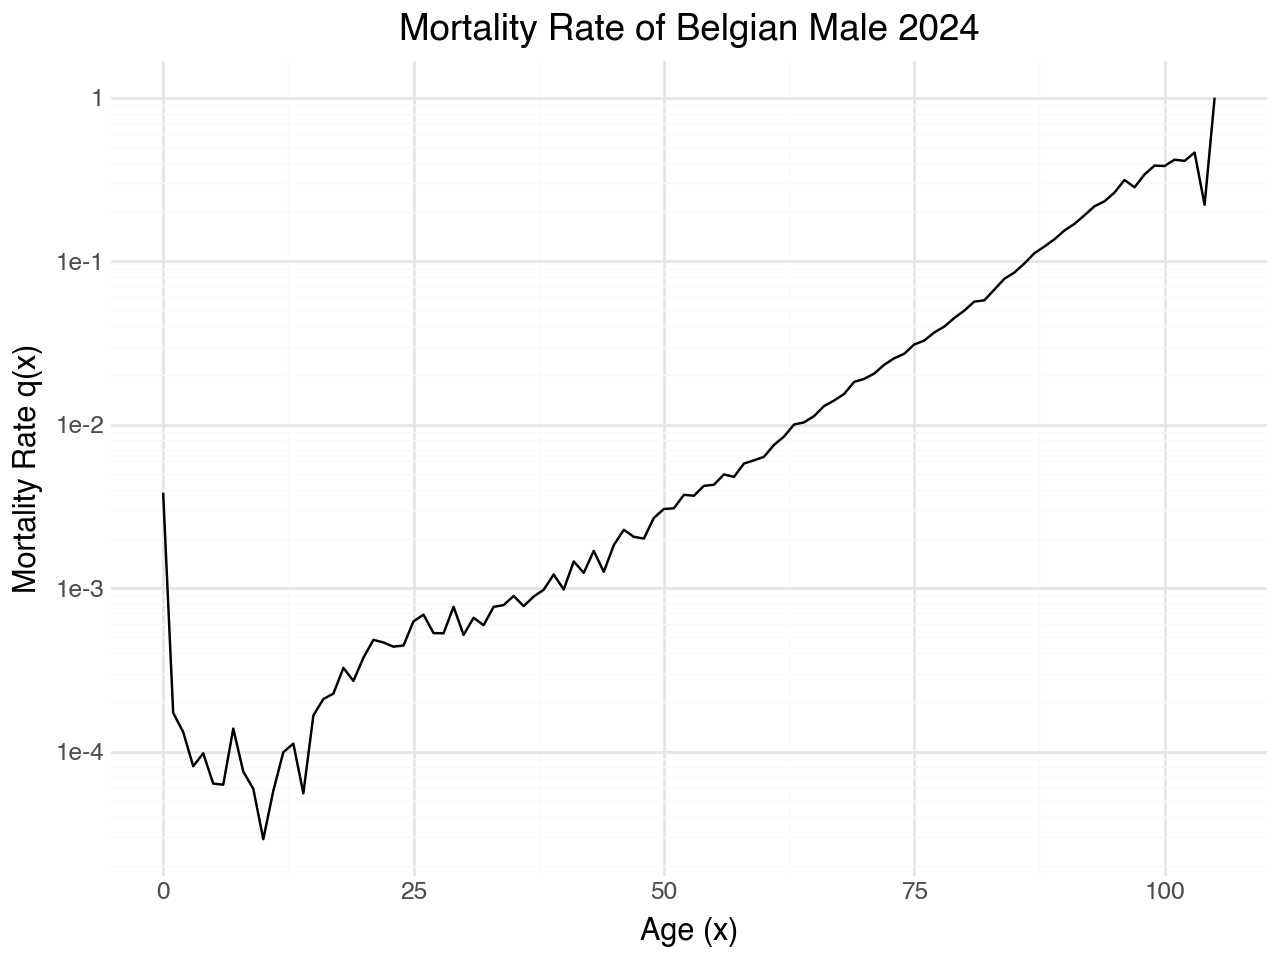

In [4]:
# Plot mortality rates
lt_BE_M_2024.plot()

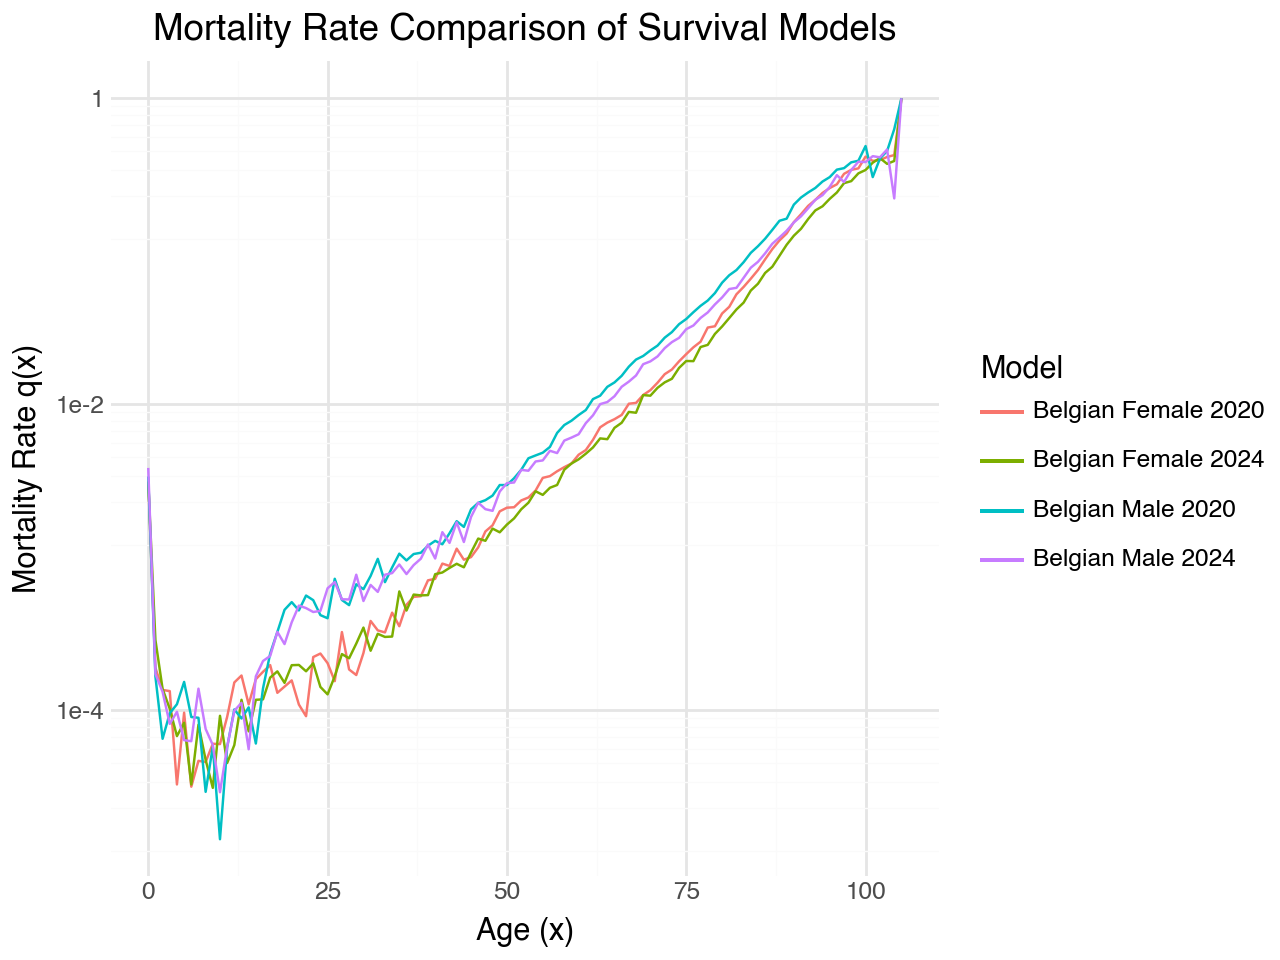

In [5]:
# Compare mortality rates
plot_mortality_rate(lt_BE_M_2024, lt_BE_F_2024, lt_BE_M_2020, lt_BE_F_2020)

In [9]:
print("The change I will die before 70 is:", lt_BE_M_2024.q(30, 40))
print("The change I will die before 80 is:", lt_BE_M_2024.q(30, 50))
print("The change I will die before 90 is:", lt_BE_M_2024.q(30, 60))
print("My average remaining life expectancy is:", lt_BE_M_2024.e(30))

The change I will die before 70 is: 0.168609652170441
The change I will die before 80 is: 0.3872797046277793
The change I will die before 90 is: 0.7523325591418386
My average remaining life expectancy is: 69.21554920385334


### Examples from book

In [3]:
l_x = [10000.00, 9965.22, 9927.12, 9885.35, 9839.55, 9789.29, 9734.12, 9673.56, 9607.07, 9534.08, 9534.08 - 80.11]
lt = LifeTable(lx=l_x, x0=30, description = "Example 3.1")

In [4]:
lt.df_curated

x,l_x,p_x,q_x,e_x
i64,f64,f64,f64,f64
30,10000.0,0.996522,0.003478,9.944019
31,9965.22,0.996177,0.003823,8.947497
32,9927.12,0.995792,0.004208,7.951321
33,9885.35,0.995367,0.004633,6.955528
34,9839.55,0.994892,0.005108,5.960161
…,…,…,…,…
36,9734.12,0.993779,0.006221,3.970905
37,9673.56,0.993127,0.006873,2.977127
38,9607.07,0.992402,0.007598,1.984


In [5]:
lt.p(30, t=10)

0.9453969999999999

In [6]:
lt.q(35)

0.00563575090736923

In [7]:
lt.q(30, t=5)

0.02107099999999995

In [9]:
lt.q(30, t=1, u=5)

0.005517000000000053

## 2. Parametric Survival Models


### Example 2.1


In [2]:
F0 = lambda x: 1 - (1 - x/120)**(1/6)
model1 = SurvivalModelParametric(x0=0, w=120, F_0=F0, description="Example 3.2")

/Users/rubencoppens/Documents/LifeContingentRisk/.venv/lib/python3.13/site-packages/chebpy/chebtech.py:110: UserWarning: The Chebtech constructor did not converge: using 65537 points
/Users/rubencoppens/Documents/LifeContingentRisk/.venv/lib/python3.13/site-packages/chebpy/algorithms.py:199: RuntimeWarning: overflow encountered in multiply
/Users/rubencoppens/Documents/LifeContingentRisk/.venv/lib/python3.13/site-packages/chebpy/algorithms.py:199: RuntimeWarning: invalid value encountered in subtract


<Axes: >

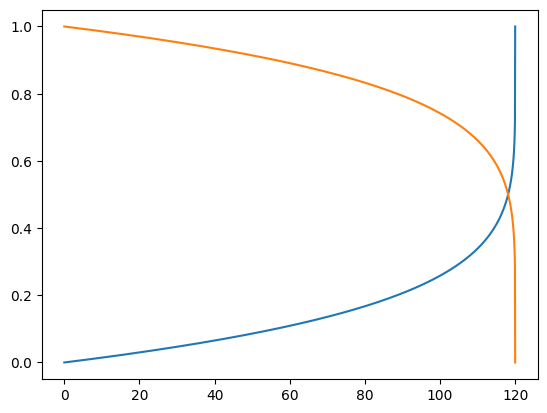

In [3]:
ax = model1.F_0.plot(label = "F_0(x)")
model1.S_0.plot(label = "S_0(x)", ax=ax)

/Users/rubencoppens/Documents/LifeContingentRisk/.venv/lib/python3.13/site-packages/plotnine/geoms/geom_path.py:100: PlotnineWarning: geom_path: Removed 1 rows containing missing values.


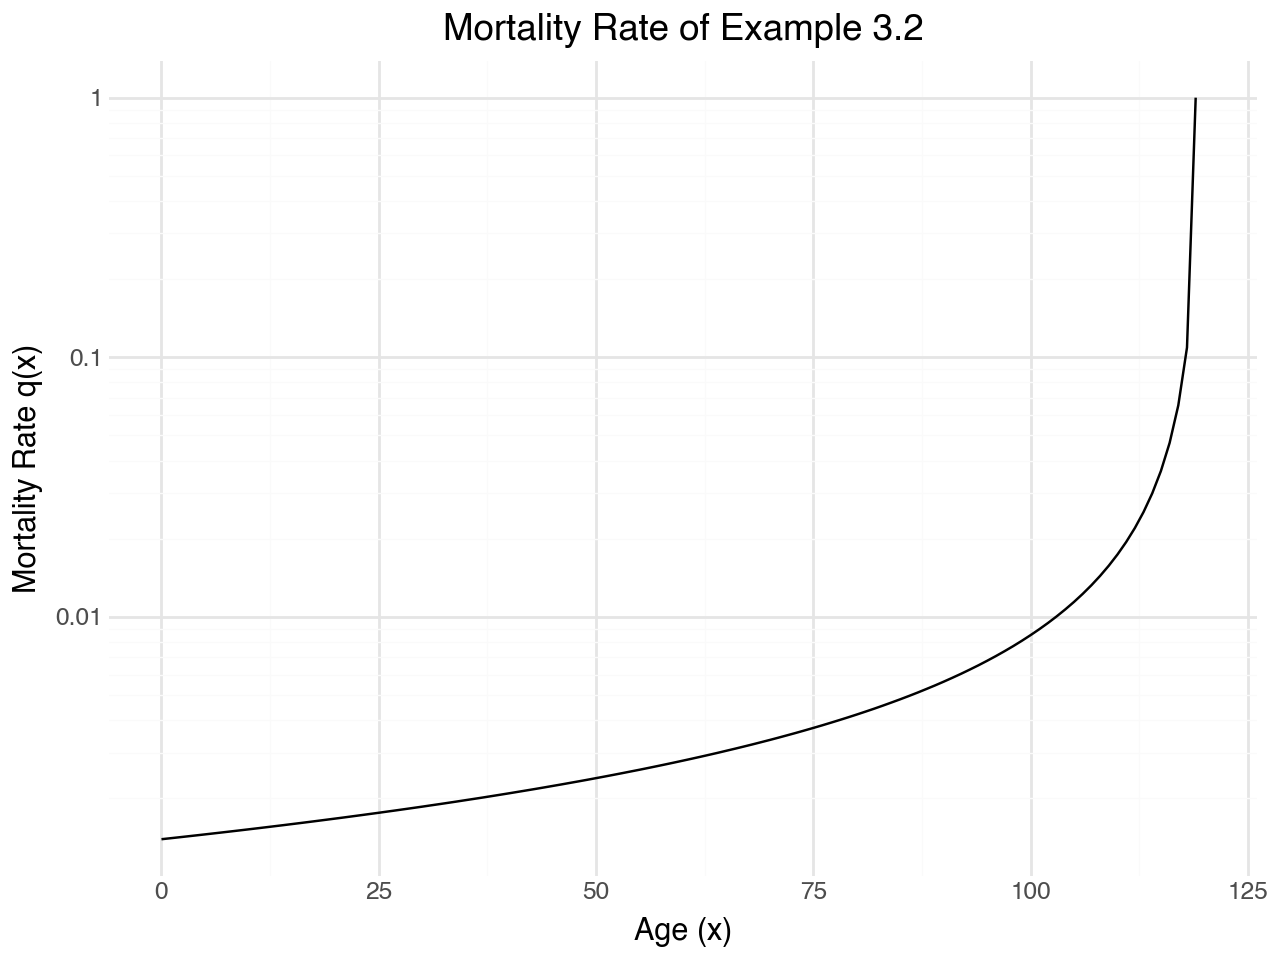

In [4]:
model1.plot()

In [5]:
model1.p(0, 30)

np.float64(0.953184200274292)

In [11]:
model1.q(30, 20)

np.float64(0.04102050987074257)

In [12]:
model1.p(40, 25)

np.float64(0.9394611736326479)

### Example 2.3

In [2]:
def makeham_mortality_rate(A, B, C):
    return lambda x: A + B * C**x

mu = makeham_mortality_rate(A=0, B=0.0003, C=1.07)
from chebpy import chebfun
mu_cheb = chebfun(mu, [0, 120])

<Axes: >

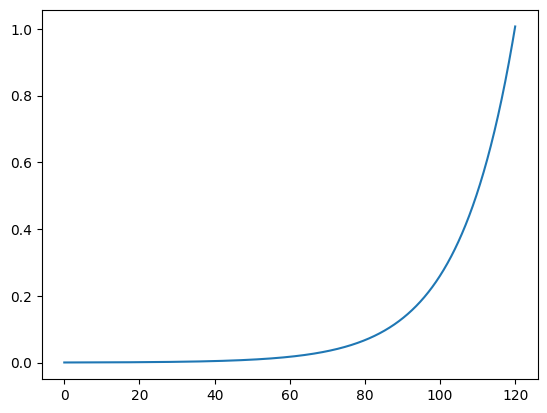

In [4]:
mu_cheb.plot(label = "Makeham Mortality Rate")

In [7]:
import math
inte = math.exp(-mu_cheb.cumsum())

TypeError: must be real number, not Chebfun

<Axes: >

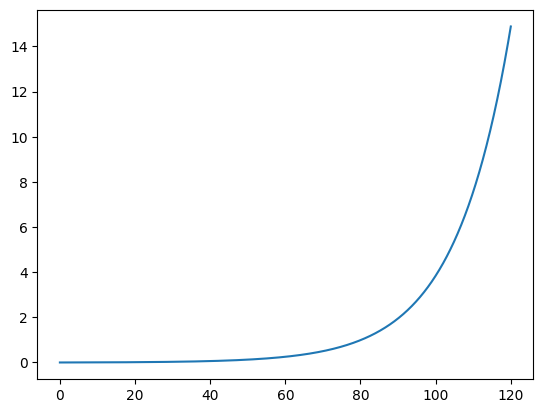

In [6]:
inte.plot(label = "Cumulative Mortality Rate")

In [3]:
mu_cheb(30)

np.float64(0.002283676512798649)

### Example 2.5

In [6]:
model1.q(20)

np.float64(0.0016736434221954477)

In [9]:
model1.mu(1)

np.float64(-5479918754.972717)

In [7]:
model1.q(110)

np.float64(0.01740660457385035)